In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Discontinuities Based Segmentation

## Point Detection

In [2]:
img = cv2.imread("stars.jpg",cv2.IMREAD_GRAYSCALE)
img

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(640, 640), dtype=uint8)

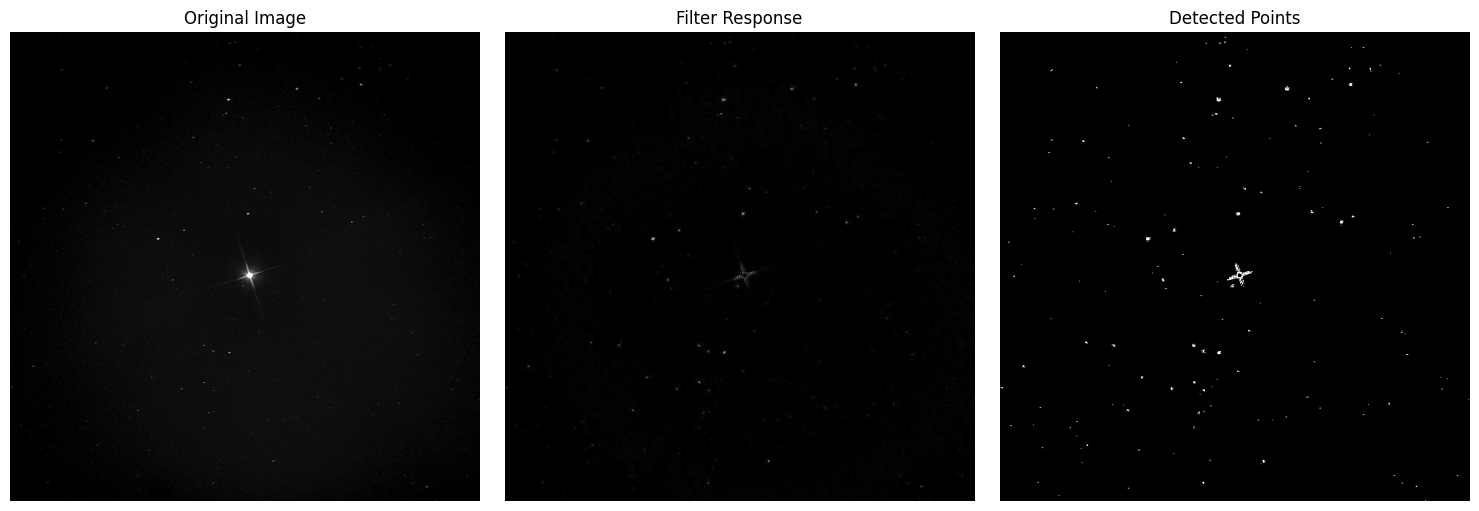

In [3]:
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]], dtype=np.float32)

def convolution(img, kernel):

    rows, cols = img.shape
    k_size = 3
    pad= k_size // 2
    padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT)

    output = np.zeros((rows, cols), dtype=np.float32)

    for i in range(rows):
        for j in range(cols):

            region = padded[i:i+k_size, j:j+k_size]

            output[i, j] = np.sum(region * kernel)
    return output

response = convolution(img, kernel)
response = np.abs(response)

response_display = cv2.normalize(response, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8) #source, destination, min, max, type

threshold = 120

points = np.zeros_like(img)
points[response > threshold] = 255

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(response_display, cmap='gray')
plt.title("Filter Response")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(points, cmap='gray')
plt.title("Detected Points")
plt.axis('off')

plt.tight_layout()
plt.show()

## Line Detection

In [8]:
img = cv2.imread("wire.jpg",cv2.IMREAD_GRAYSCALE)
img

[ WARN:0@1235.855] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@1235.855] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@1235.855] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@1235.855] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@1235.855] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@1235.855] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@1235.855] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@1235.855] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], shape=(486, 486), dtype=uint8)

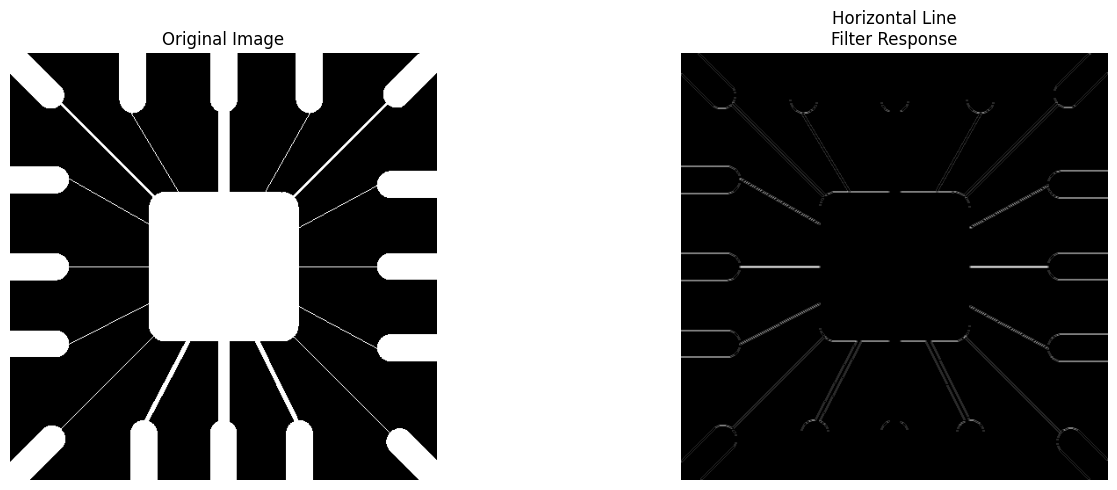

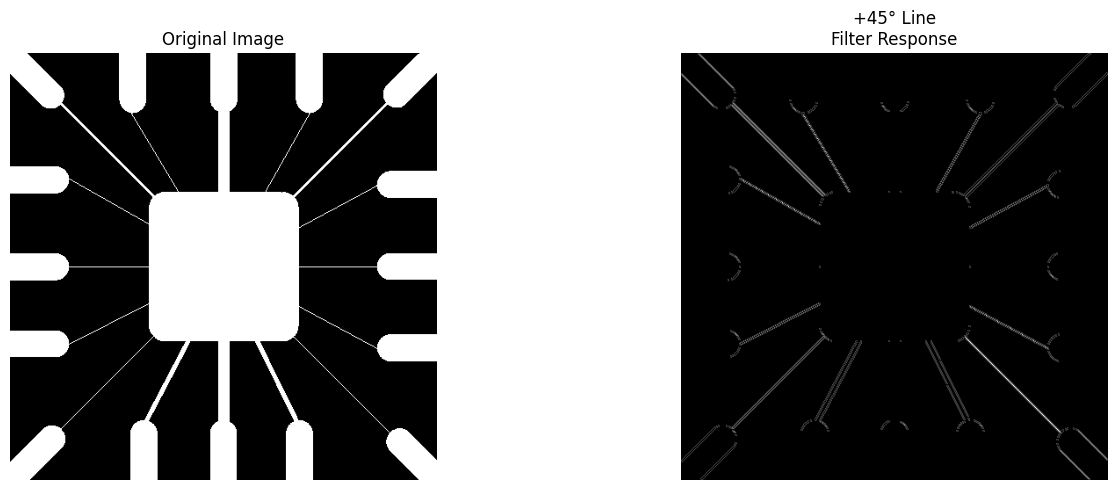

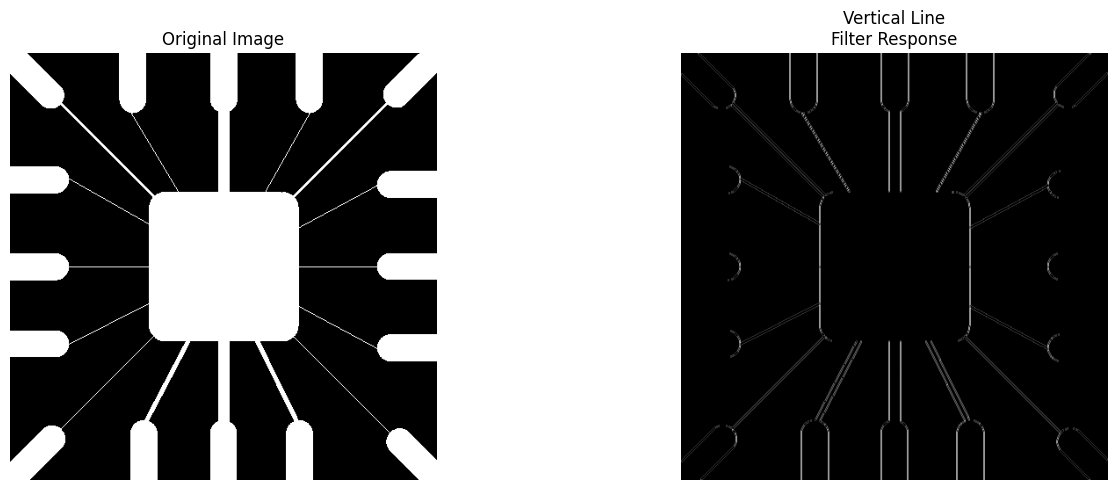

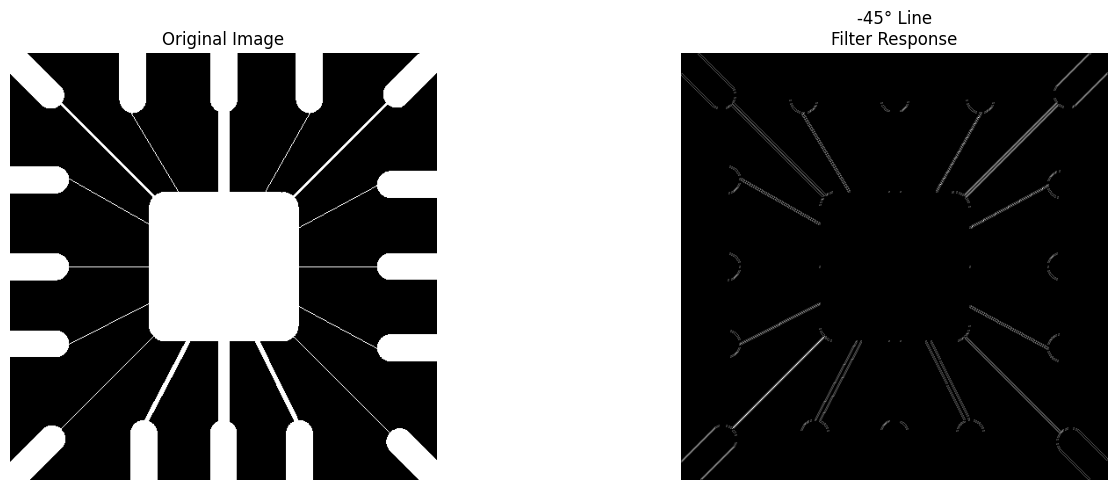

In [9]:
def convolution(img, kernel):

    rows, cols = img.shape
    k_size = 3
    pad = k_size // 2

    padded = cv2.copyMakeBorder(
        img,
        pad, pad,
        pad, pad,
        cv2.BORDER_REFLECT
    )

    output = np.zeros((rows, cols), dtype=np.float32)

    for i in range(rows):
        for j in range(cols):

            region = padded[i:i+k_size, j:j+k_size]

            output[i, j] = np.sum(region * kernel)

    return output

kernels = {
    "Horizontal Line":
    np.array([[-1, -1, -1],
              [ 2,  2,  2],
              [-1, -1, -1]], dtype=np.float32),
    "+45° Line":
    np.array([[ 2, -1, -1],
              [-1,  2, -1],
              [-1, -1,  2]], dtype=np.float32),
    "Vertical Line":
    np.array([[-1,  2, -1],
              [-1,  2, -1],
              [-1,  2, -1]], dtype=np.float32),
    "-45° Line":
    np.array([[-1, -1,  2],
              [-1,  2, -1],
              [ 2, -1, -1]], dtype=np.float32)
}
threshold = 80

for title, kernel in kernels.items():

    response = convolution(img, kernel)
    response = np.abs(response)

    response_display = cv2.normalize(response, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    plt.figure(figsize=(15,5))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.imshow(response_display, cmap='gray')
    plt.title(title + "\nFilter Response")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

## Edge Detection - Sobel's Filter

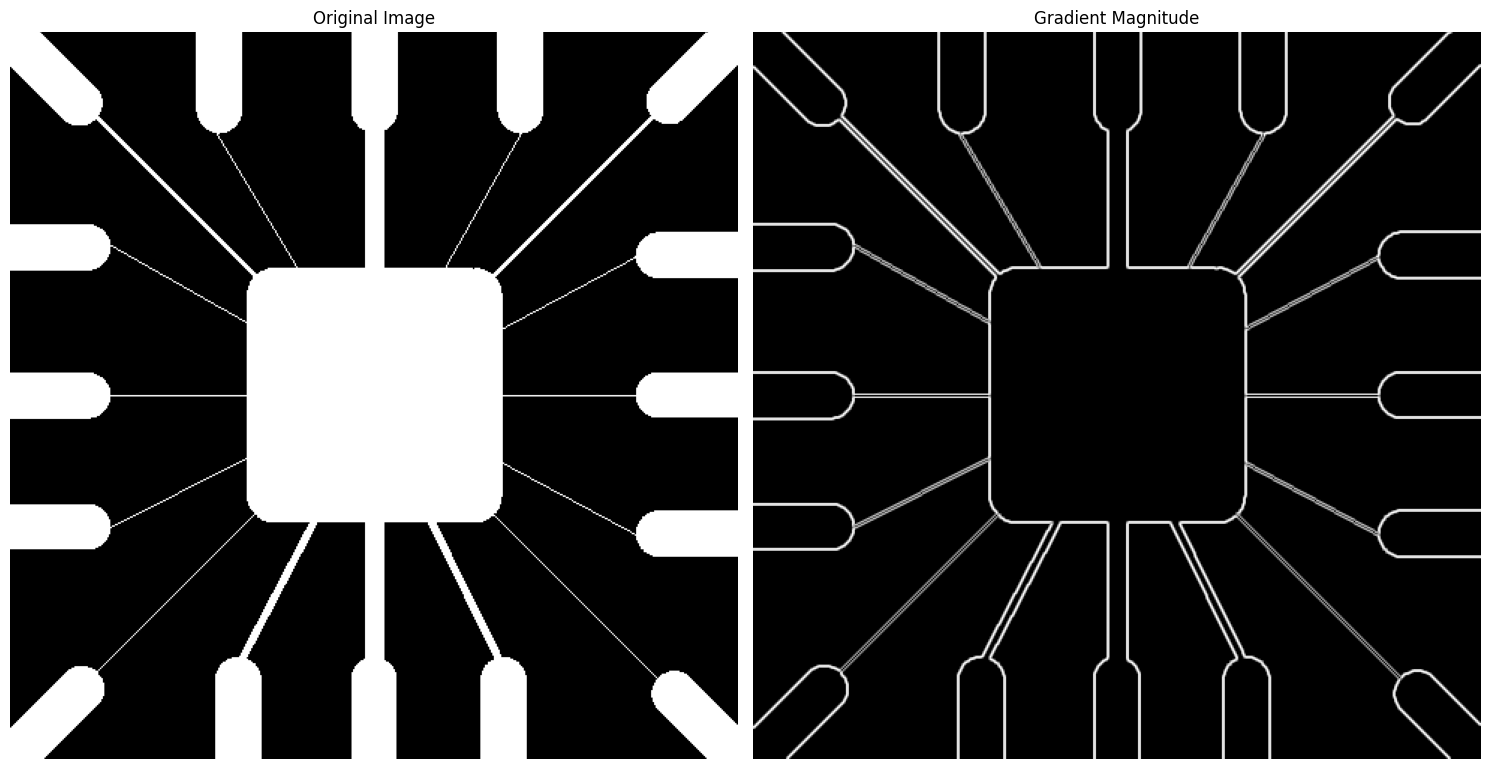

In [10]:
Gx = np.array([[-1, 0, 1],
               [-2, 0, 2],
               [-1, 0, 1]], dtype=np.float32)

Gy = np.array([[-1, -2, -1],
               [ 0,  0,  0],
               [ 1,  2,  1]], dtype=np.float32)

def convolution(img, kernel):
    rows, cols = img.shape
    k_size = 3
    pad = k_size // 2
    padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    output = np.zeros((rows, cols), dtype=np.float32)
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+k_size, j:j+k_size]
            output[i, j] = np.sum(region * kernel)
    return output

sobel_x = convolution(img, Gx)
sobel_y = convolution(img, Gy)

magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
response = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(15,10))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(response, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis("off")

plt.tight_layout()
plt.show()

## Laplacian 8-Neighbour Filter

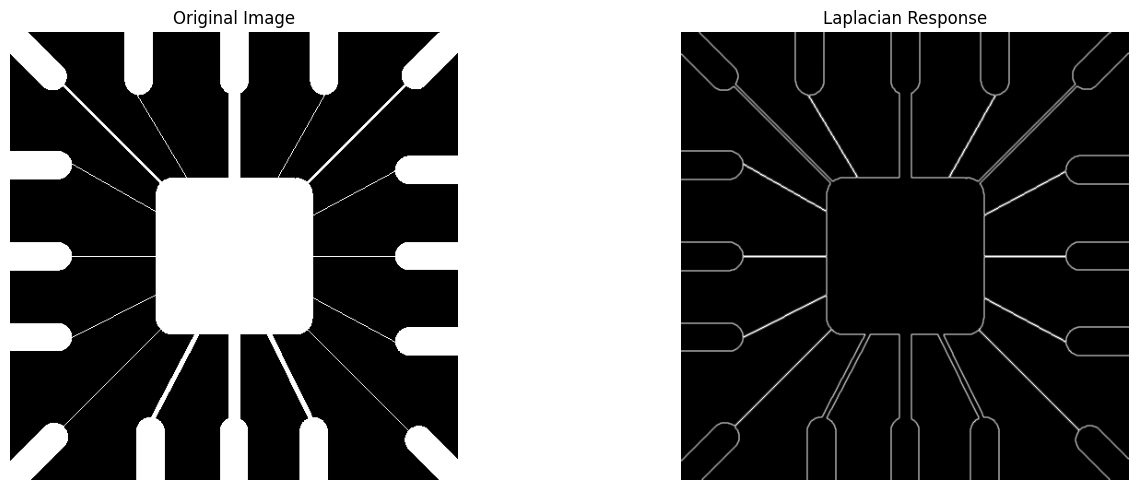

In [11]:
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]], dtype=np.float32)

def convolution(img, kernel):
    rows, cols = img.shape
    k_size = 3
    pad = k_size // 2
    padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    output = np.zeros((rows, cols), dtype=np.float32)
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+k_size, j:j+k_size]
            output[i, j] = np.sum(region * kernel)
    return output

laplacian = convolution(img, kernel)

laplacian_abs = np.abs(laplacian)

laplacian_display = cv2.normalize(laplacian_abs, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(laplacian_display, cmap='gray')
plt.title("Laplacian Response")
plt.axis('off')

plt.tight_layout()
plt.show()

## Maxican Hat Filter

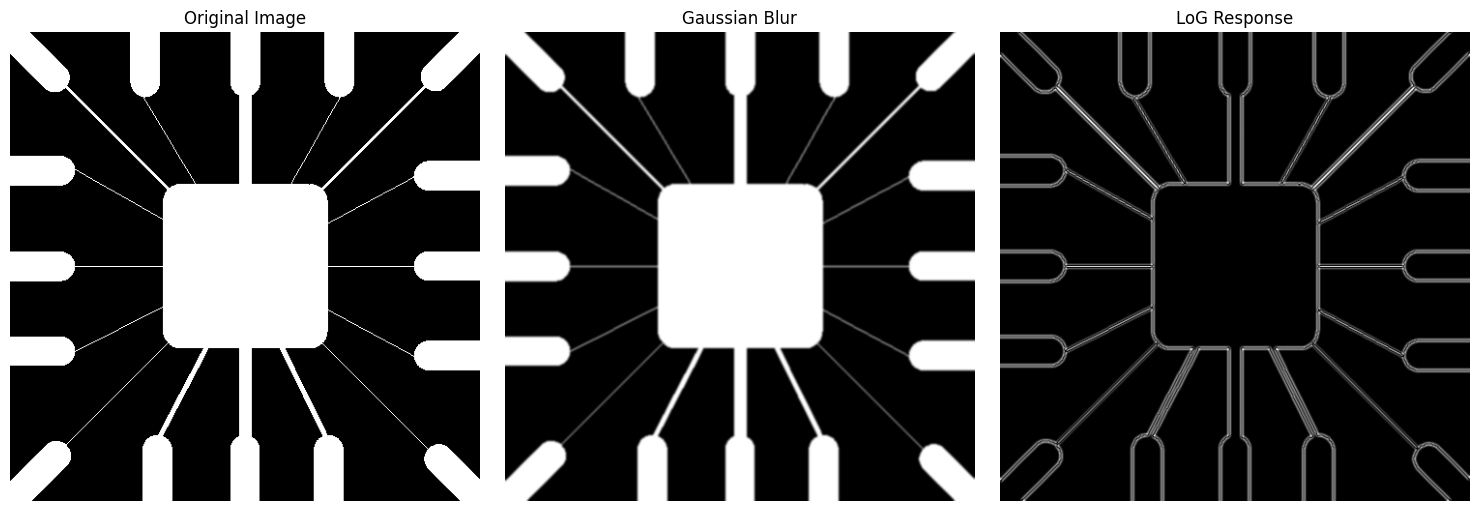

In [12]:
blur = cv2.GaussianBlur(img, (5, 5), 1)

lap = cv2.Laplacian(blur, cv2.CV_64F, ksize=3)

lap_abs = np.abs(lap)

lap_norm = cv2.normalize(lap_abs, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(blur, cmap='gray')
plt.title("Gaussian Blur")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(lap_norm, cmap='gray')
plt.title("LoG Response")
plt.axis('off')

plt.tight_layout()
plt.show()

## Canny Edge Detector

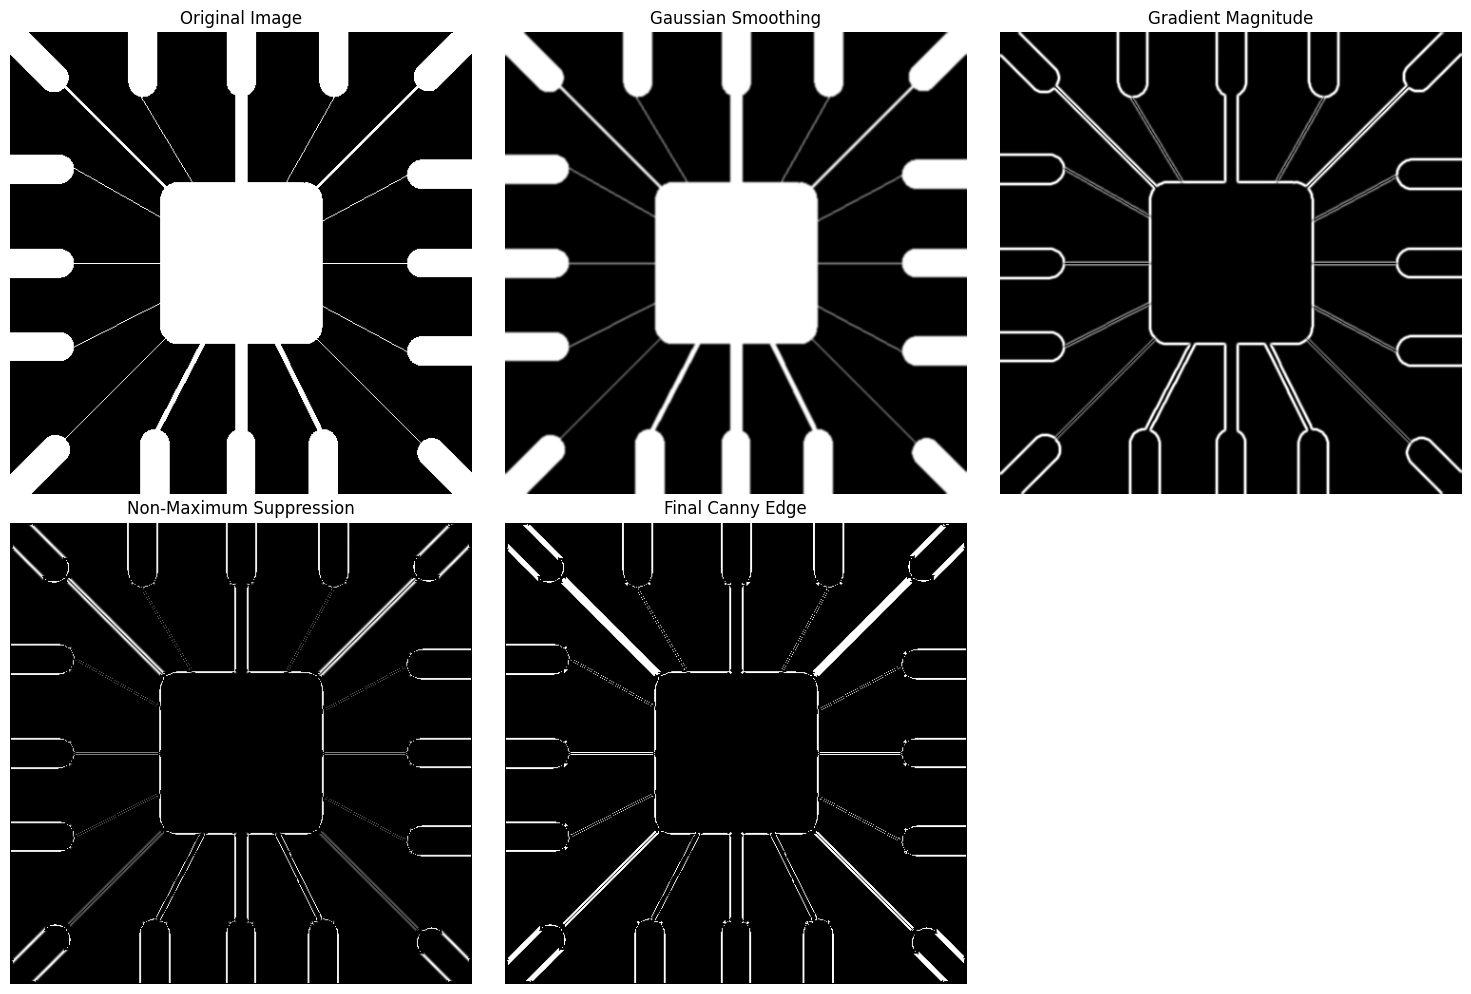

In [13]:
def convolution(img, kernel):

    rows, cols = img.shape
    k = kernel.shape[0]
    pad = k // 2

    padded = cv2.copyMakeBorder(
        img,
        pad, pad,
        pad, pad,
        cv2.BORDER_REFLECT
    )

    output = np.zeros((rows, cols), dtype=np.float32)

    for i in range(rows):
        for j in range(cols):

            region = padded[i:i+k, j:j+k]
            output[i, j] = np.sum(region * kernel)

    return output

# Gaussian Smoothing
smooth = cv2.GaussianBlur(img, (5, 5), 1)

# Sobel Gradients
Gx_kernel = np.array([[-1,0,1],
                      [-2,0,2],
                      [-1,0,1]], dtype=np.float32)

Gy_kernel = np.array([[-1,-2,-1],
                      [ 0, 0, 0],
                      [ 1, 2, 1]], dtype=np.float32)

Gx = convolution(smooth, Gx_kernel)
Gy = convolution(smooth, Gy_kernel)

# Gradient Magnitude and Direction
magnitude = np.sqrt(Gx**2 + Gy**2)
direction = np.rad2deg(np.arctan2(Gy, Gx))
direction[direction < 0] += 180

# Non-Maximum Suppression
rows, cols = magnitude.shape
nms = np.zeros((rows, cols), dtype=np.float32)

for i in range(1, rows-1):
    for j in range(1, cols-1):

        angle = direction[i, j]

        if (0 <= angle < 22.5) or (157.5 <= angle <= 180):
            q = magnitude[i, j+1]
            r = magnitude[i, j-1]

        elif 22.5 <= angle < 67.5:
            q = magnitude[i+1, j-1]
            r = magnitude[i-1, j+1]

        elif 67.5 <= angle < 112.5:
            q = magnitude[i+1, j]
            r = magnitude[i-1, j]

        else:
            q = magnitude[i-1, j-1]
            r = magnitude[i+1, j+1]

        if magnitude[i, j] >= q and magnitude[i, j] >= r:
            nms[i, j] = magnitude[i, j]

# Double Threshold
high = nms.max() * 0.20
low = high * 0.50

strong = 255
weak = 75

edges = np.zeros_like(nms, dtype=np.uint8)

strong_i, strong_j = np.where(nms >= high)
weak_i, weak_j = np.where((nms >= low) & (nms < high))

edges[strong_i, strong_j] = strong
edges[weak_i, weak_j] = weak

# Edge Tracking by Hysteresis
rows, cols = edges.shape

for i in range(1, rows-1):
    for j in range(1, cols-1):

        if edges[i, j] == weak:

            if np.any(edges[i-1:i+2, j-1:j+2] == strong):
                edges[i, j] = strong
            else:
                edges[i, j] = 0

smooth_disp = smooth.astype(np.uint8)

mag_disp = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

nms_disp = cv2.normalize(nms, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(15,10))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(smooth_disp, cmap='gray')
plt.title("Gaussian Smoothing")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(mag_disp, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(nms_disp, cmap='gray')
plt.title("Non-Maximum Suppression")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(edges, cmap='gray')
plt.title("Final Canny Edge")
plt.axis("off")

plt.tight_layout()
plt.show()

# Edge Linking

## Local Edge Linking - using magnitude and gradient threshold

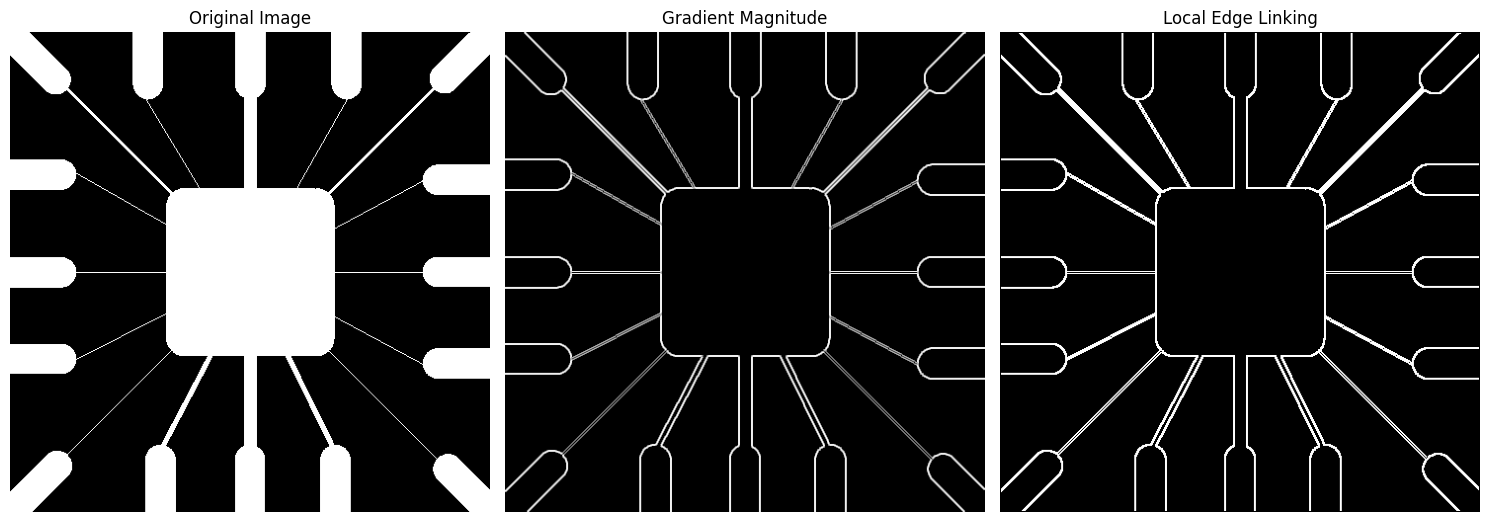

In [14]:
Gx_kernel = np.array([[-1, 0, 1],
                      [-1, 0, 1],
                      [-1, 0, 1]], dtype=np.float32)

Gy_kernel = np.array([[-1, -1, -1],
                      [ 0,  0,  0],
                      [ 1,  1,  1]], dtype=np.float32)

def convolution(img, kernel):
    rows, cols = img.shape
    pad = 1
    padded = cv2.copyMakeBorder(img, pad, pad, pad, pad, cv2.BORDER_REFLECT)
    output = np.zeros((rows, cols), dtype=np.float32)
    for i in range(rows):
        for j in range(cols):
            region = padded[i:i+3, j:j+3]
            output[i, j] = np.sum(region * kernel)
    return output

Gx = convolution(img, Gx_kernel)
Gy = convolution(img, Gy_kernel)

magnitude = np.sqrt(Gx**2 + Gy**2)

direction = np.degrees(np.arctan2(Gy, Gx))
direction[direction < 0] += 180

# Local Edge Linking
magnitude_threshold = 80
angle_threshold = 20 # degrees

rows, cols = img.shape
linked = np.zeros((rows, cols), dtype=np.uint8)

for i in range(1, rows-1):
    for j in range(1, cols-1):
        if magnitude[i, j] >= magnitude_threshold: # Candidate edge pixel
            current_angle = direction[i, j]
            # Check 8-neighbors
            for r in range(i-1, i+2):
                for c in range(j-1, j+2):
                    if r == i and c == j:
                        continue
                    if magnitude[r, c] >= magnitude_threshold:
                        angle_diff = abs(current_angle - direction[r, c])
                        angle_diff = min(angle_diff, 180 - angle_diff) # Handle wrap-around (0° and 180°)
                        if angle_diff <= angle_threshold:
                            linked[i, j] = 255
                            break
                if linked[i, j] == 255:
                    break

mag_display = cv2.normalize(magnitude, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

plt.figure(figsize=(15,8))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(mag_display, cmap='gray')
plt.title("Gradient Magnitude")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(linked, cmap='gray')
plt.title("Local Edge Linking")
plt.axis('off')

plt.tight_layout()
plt.show()

## Global Edge Linking using Hough Transform

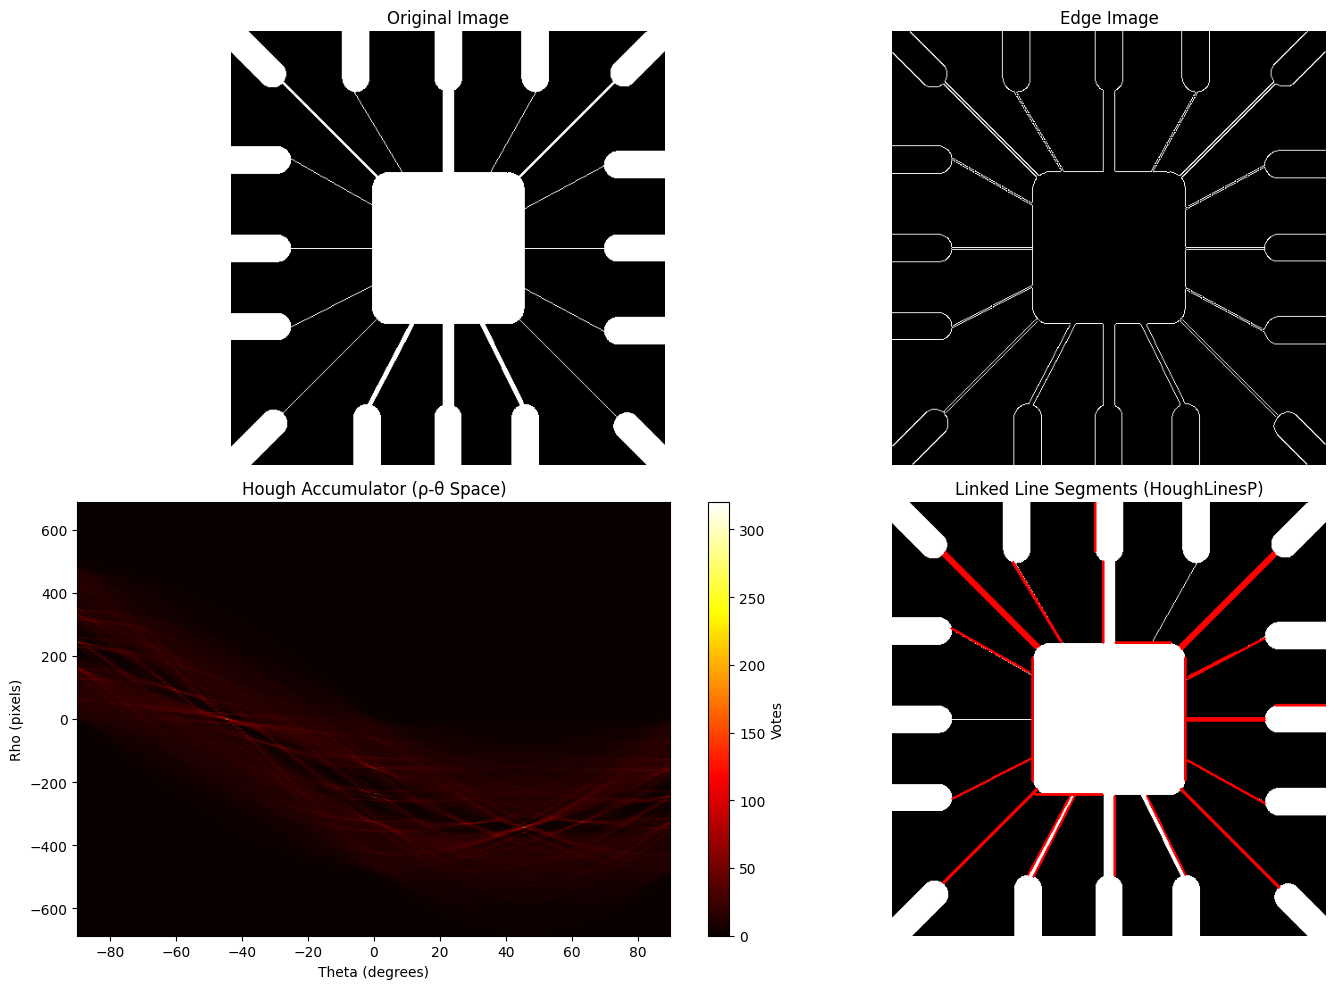

In [15]:
edges = cv2.Canny(img, 50, 150)

rows, cols = edges.shape
diag_len = int(np.sqrt(rows**2 + cols**2)) #diagonal length is largest possible values of rho

thetas = np.deg2rad(np.arange(-90, 90))
rhos = np.arange(-diag_len, diag_len + 1) 

accumulator = np.zeros((len(rhos), len(thetas)), dtype=np.uint64)

# Edge pixel coordinates
y_idxs, x_idxs = np.nonzero(edges) # x-indices and y-indices of non-zero edges

for x, y in zip(x_idxs, y_idxs): #zip iterates multiple values

    for t in range(len(thetas)):

        rho = int(round(x*np.cos(thetas[t]) +
                        y*np.sin(thetas[t])))

        accumulator[rho + diag_len, t] += 1

# Probabilistic Hough Transform
lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi/180, threshold=80, minLineLength=50, maxLineGap=10)

result = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

if lines is not None:

    for line in lines:

        x1, y1, x2, y2 = line[0]

        cv2.line(result,(x1, y1), (x2, y2), (0, 0, 255), 2) # draw red lines to represent connected lines

plt.figure(figsize=(15,10))

plt.subplot(2,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(edges, cmap="gray")
plt.title("Edge Image")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(accumulator,
           cmap="hot",
           aspect="auto",
           extent=[-90, 90, -diag_len, diag_len])

plt.xlabel("Theta (degrees)")
plt.ylabel("Rho (pixels)")
plt.title("Hough Accumulator (ρ-θ Space)")
plt.colorbar(label="Votes")

plt.subplot(2,2,4)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Linked Line Segments (HoughLinesP)")
plt.axis("off")

plt.tight_layout()
plt.show()

# Thresholding for Segmentation

In [17]:
img = cv2.imread("yeast.tif",cv2.IMREAD_GRAYSCALE)
img

[ WARN:0@1533.170] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34016 (0x84e0) encountered
[ WARN:0@1533.170] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34017 (0x84e1) encountered
[ WARN:0@1533.170] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34018 (0x84e2) encountered
[ WARN:0@1533.170] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34019 (0x84e3) encountered
[ WARN:0@1533.170] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34020 (0x84e4) encountered
[ WARN:0@1533.170] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34021 (0x84e5) encountered
[ WARN:0@1533.170] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34022 (0x84e6) encountered
[ WARN:0@1533.170] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 34023 (0x84

array([[8, 8, 8, ..., 8, 8, 8],
       [8, 8, 8, ..., 8, 8, 8],
       [8, 8, 8, ..., 8, 8, 8],
       ...,
       [8, 8, 8, ..., 8, 8, 8],
       [8, 8, 8, ..., 8, 8, 8],
       [8, 8, 8, ..., 8, 8, 8]], shape=(818, 710), dtype=uint8)

## Global Thresholding

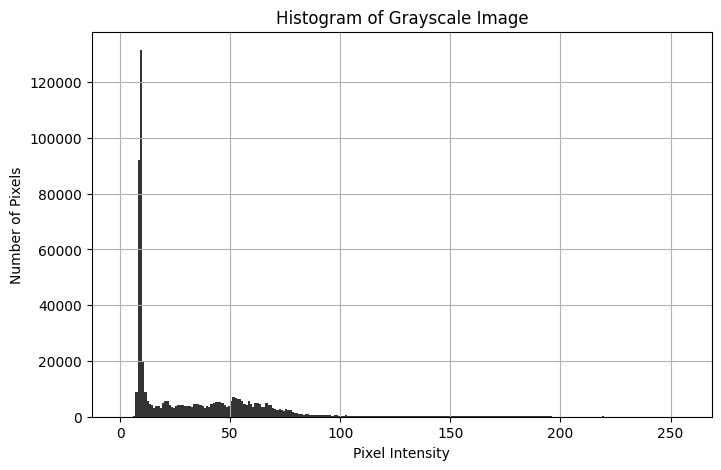

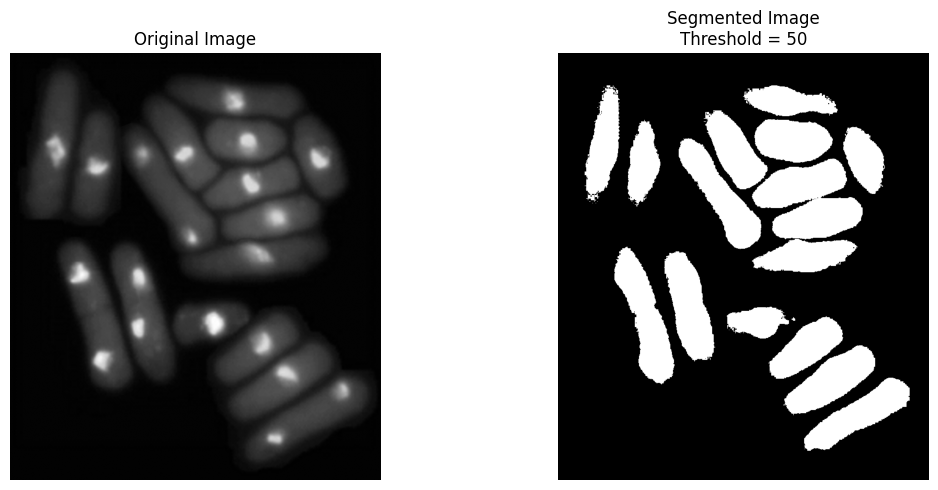

In [19]:
plt.figure(figsize=(8,5))
plt.hist(img.ravel(), bins=256, range=[0,256],
         color='black', alpha=0.8)

plt.title("Histogram of Grayscale Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Number of Pixels")
plt.grid(True)

plt.show()

threshold = 50 # Change this after observing histogram

_, segmented = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented, cmap='gray')
plt.title(f"Segmented Image\nThreshold = {threshold}")
plt.axis("off")

plt.tight_layout()
plt.show()

## Multivalued Threshold

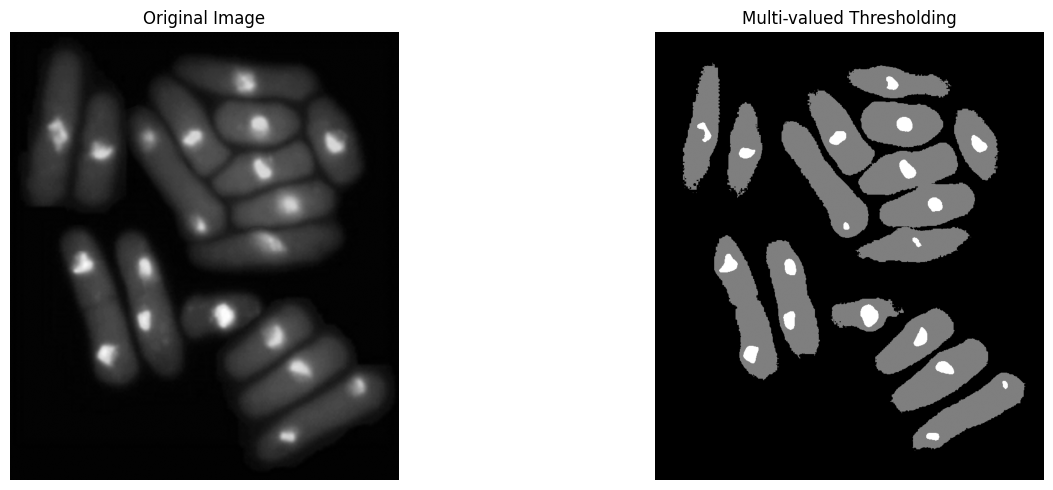

In [21]:
T1 = 50
T2 = 150

segmented = np.zeros_like(img)
segmented[img < T1] = 0 # Region 1 (Black)
segmented[(img >= T1) & (img < T2)] = 127 # Region 2 (Gray)
segmented[img >= T2] = 255 # Region 3 (White)

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented, cmap='gray')
plt.title("Multi-valued Thresholding")
plt.axis("off")

plt.tight_layout()
plt.show()

## Adaptive Threshold

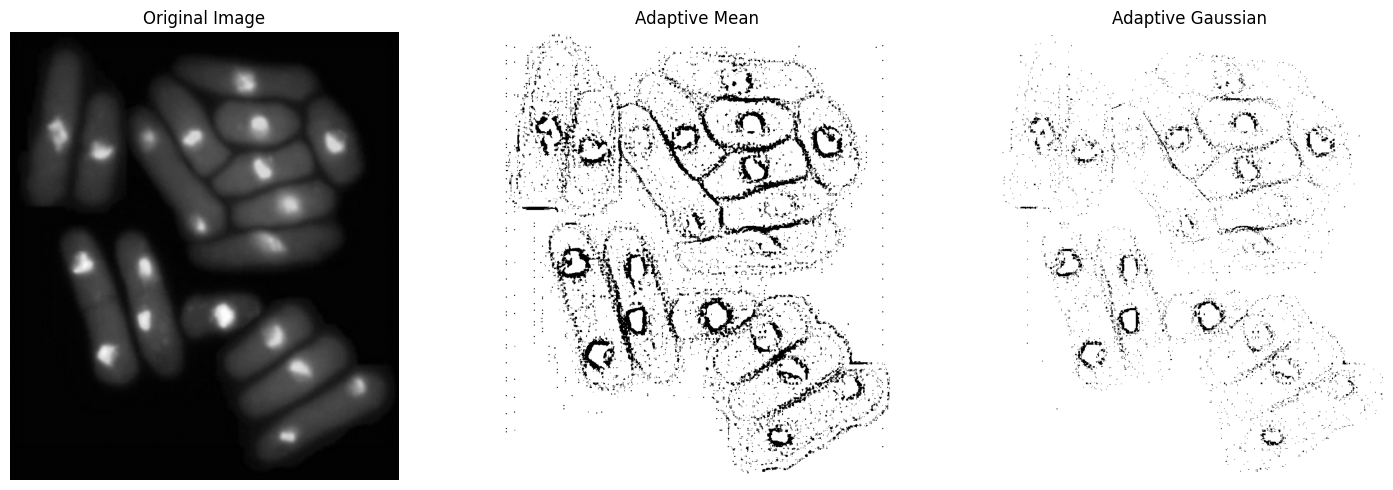

In [22]:
adaptive_mean = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY,11,2)
# calculates threshold value using mean of block - constant 
adaptive_gaussian = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY,11,2)
#calculates threshold value using weighted average of block - constant 
#cv2.adaptiveThreshold(src, maxValue, adaptiveMethod, thresholdType, blockSize,Constant)
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap="gray")
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(adaptive_mean, cmap="gray")
plt.title("Adaptive Mean")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(adaptive_gaussian, cmap="gray")
plt.title("Adaptive Gaussian")
plt.axis("off")

plt.tight_layout()
plt.show()

## Optimum Thresholding (Otsu's Algorithm)

Optimum Threshold = 42


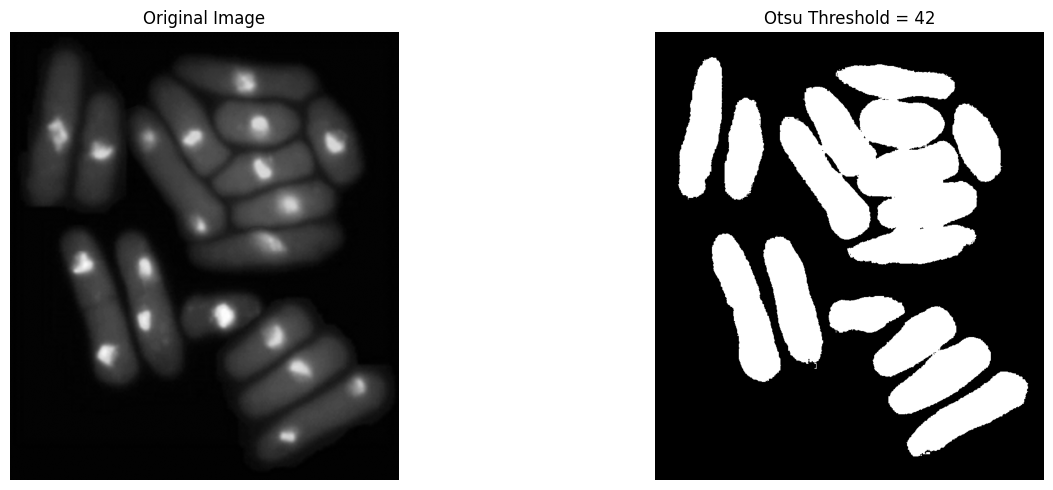

In [23]:
hist = np.zeros(256)
for pixel in img.ravel():
    hist[pixel] += 1

total_pixels = img.size
prob = hist / total_pixels

global_mean = 0

for i in range(256):
    global_mean += i * prob[i]

best_threshold = 0
max_variance = 0

w0 = 0  # Background probability
mean0 = 0 # Background mean

for t in range(256):

    w0 += prob[t]

    if w0 == 0:
        continue

    w1 = 1 - w0

    if w1 == 0:
        break

    mean0 += t * prob[t]

    mu0 = mean0 / w0
    mu1 = (global_mean - mean0) / w1

    variance = w0 * w1 * (mu0 - mu1) ** 2 # Between-class variance

    if variance > max_variance:
        max_variance = variance
        optimum_threshold = t
print("Optimum Threshold =", optimum_threshold)

segmented = np.zeros_like(img)
segmented[img > optimum_threshold] = 255

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(segmented, cmap='gray')
plt.title(f"Otsu Threshold = {optimum_threshold}")
plt.axis('off')

plt.tight_layout()
plt.show()

# Using Edge to Improve Thresholding

## Gradient + Laplacian guided Global Thresholding Algorithm

Optimal Threshold = 123


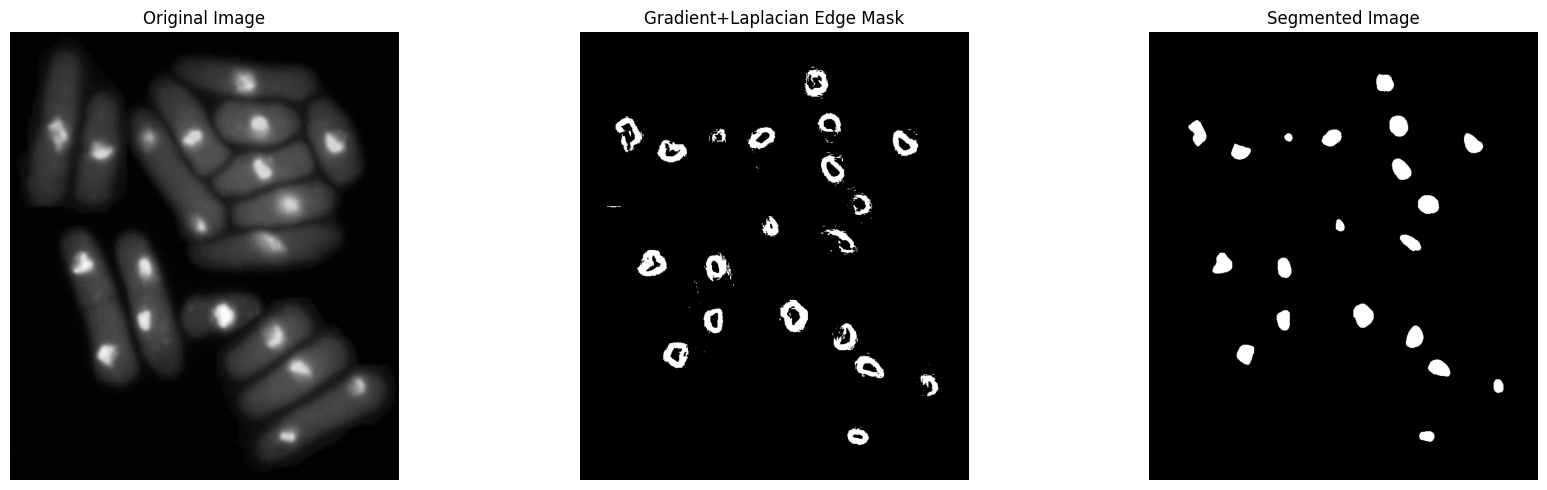

In [24]:
gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)

gradient = np.sqrt(gx**2 + gy**2)

laplacian = cv2.Laplacian(img, cv2.CV_64F)

gradient_threshold = 40

edge_mask = gradient >= gradient_threshold

# Keep pixels whose Laplacian is positive or negative
positive_edges = edge_mask & (laplacian >= 0)
negative_edges = edge_mask & (laplacian < 0)

guided_edges = positive_edges | negative_edges

edge_pixels = img[guided_edges]

hist = np.zeros(256)

for pixel in edge_pixels:
    hist[pixel] += 1

prob = hist / np.sum(hist)

global_mean = 0

for i in range(256):
    global_mean += i * prob[i]

best_threshold = 0
max_variance = 0

w0 = 0
mean0 = 0

for t in range(256):

    w0 += prob[t]

    if w0 == 0:
        continue

    w1 = 1 - w0

    if w1 == 0:
        break

    mean0 += t * prob[t]

    mu0 = mean0 / w0
    mu1 = (global_mean - mean0) / w1

    variance = w0 * w1 * (mu0 - mu1) ** 2

    if variance > max_variance:
        max_variance = variance
        best_threshold = t

print("Optimal Threshold =", best_threshold)

segmented = np.zeros_like(img)

segmented[img >= best_threshold] = 255

plt.figure(figsize=(18,5))

plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(guided_edges, cmap='gray')
plt.title("Gradient+Laplacian Edge Mask")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(segmented, cmap='gray')
plt.title("Segmented Image")
plt.axis('off')

plt.tight_layout()
plt.show()

# Similarities Bases Segmentation

## Region Growing based Segmentation - seeded

In [26]:
from collections import deque

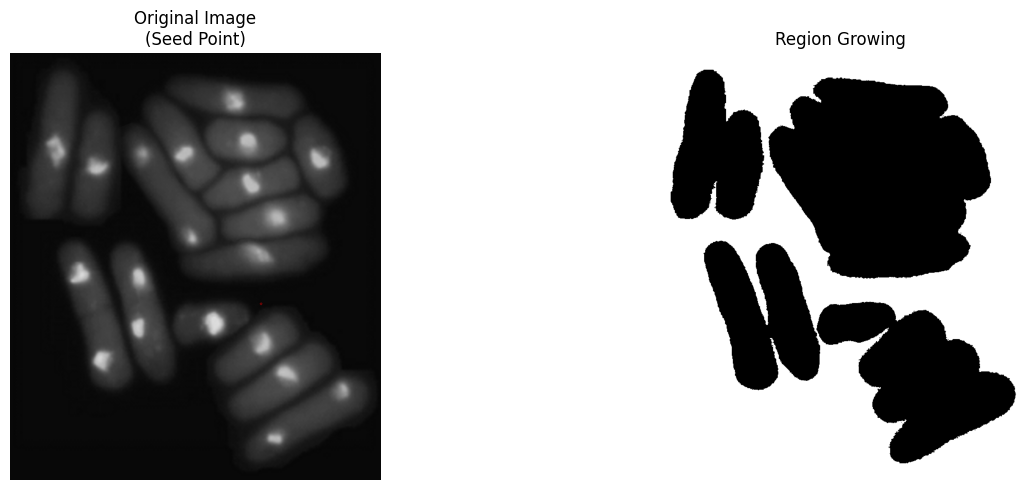

Seed Point : (480, 480)
Seed Intensity : 8
Region Size : 323831


In [27]:
seed = (480, 480)
threshold = 15 # Similarity Threshold

rows, cols = img.shape

segmented = np.zeros((rows, cols), dtype=np.uint8)

visited = np.zeros((rows, cols), dtype=bool)

queue = deque()
queue.append(seed)

visited[seed] = True
segmented[seed] = 255

region_sum = int(img[seed])
region_size = 1

neighbors = [(-1,-1), (-1,0), (-1,1),
             ( 0,-1),         ( 0,1),
             ( 1,-1), ( 1,0), ( 1,1)]

while queue:
    x, y = queue.popleft()
    region_mean = region_sum / region_size

    for dx, dy in neighbors:
        nx = x + dx
        ny = y + dy
        if (0 <= nx < rows and
            0 <= ny < cols and
            not visited[nx, ny]):

            visited[nx, ny] = True

            if abs(int(img[nx, ny]) - region_mean) <= threshold:

                segmented[nx, ny] = 255

                queue.append((nx, ny))

                region_sum += int(img[nx, ny])
                region_size += 1

image = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

cv2.circle(image,(seed[1], seed[0]), 2, (0,0,255))

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Original Image\n(Seed Point)")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(segmented, cmap='gray')
plt.title("Region Growing")
plt.axis("off")


plt.tight_layout()
plt.show()

print("Seed Point :", seed)
print("Seed Intensity :", img[seed])
print("Region Size :", region_size)

## Region Growing Based Segmentation - Unseeded

Total Regions Found = 524


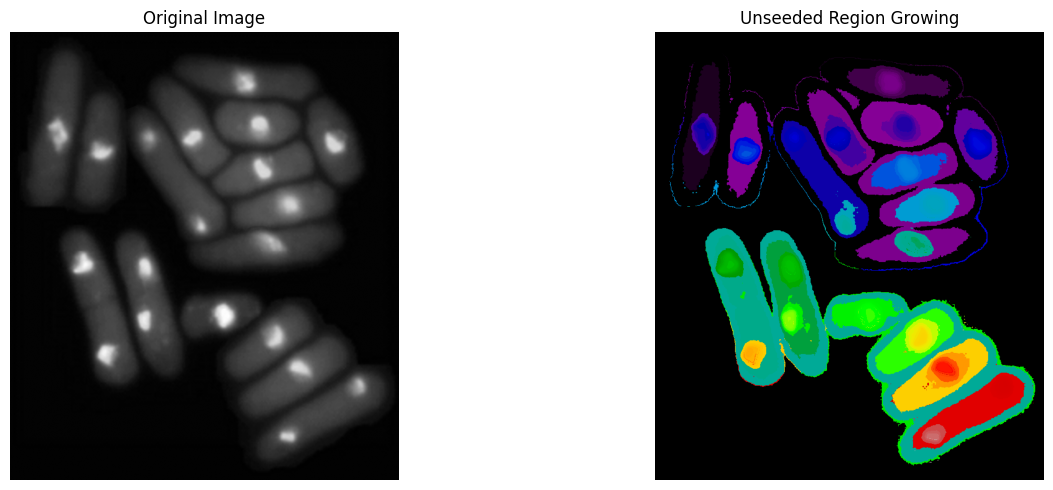

In [28]:
rows, cols = img.shape

threshold = 12 # Similarity Threshold

labels = np.zeros((rows, cols), dtype=np.int32) # Region Labels
current_label = 1
neighbors = [(-1,-1), (-1,0), (-1,1),
             ( 0,-1),         ( 0,1),
             ( 1,-1), ( 1,0), ( 1,1)]

for r in range(rows):
    for c in range(cols):
        if labels[r, c] != 0:
            continue
        queue = deque()
        queue.append((r, c))

        labels[r, c] = current_label

        region_sum = int(img[r, c])
        region_size = 1

        while queue:

            x, y = queue.popleft()

            region_mean = region_sum / region_size

            for dx, dy in neighbors:

                nx = x + dx
                ny = y + dy

                if (0 <= nx < rows and
                    0 <= ny < cols and
                    labels[nx, ny] == 0):
                    
                    if abs(int(img[nx, ny]) - region_mean) <= threshold: 

                        labels[nx, ny] = current_label

                        queue.append((nx, ny))

                        region_sum += int(img[nx, ny])
                        region_size += 1

        current_label += 1

display = np.zeros((rows, cols), dtype=np.uint8)

max_label = labels.max()
print("Total Regions Found =", max_label)
for label in range(1, max_label + 1):

    display[labels == label] = int(255 * label / max_label)

plt.figure(figsize=(15,5))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(display, cmap='nipy_spectral')
plt.title("Unseeded Region Growing")
plt.axis("off")

plt.tight_layout()
plt.show()

## Region Splitting and Merging

Regions after splitting: 1207
Final Regions: 10


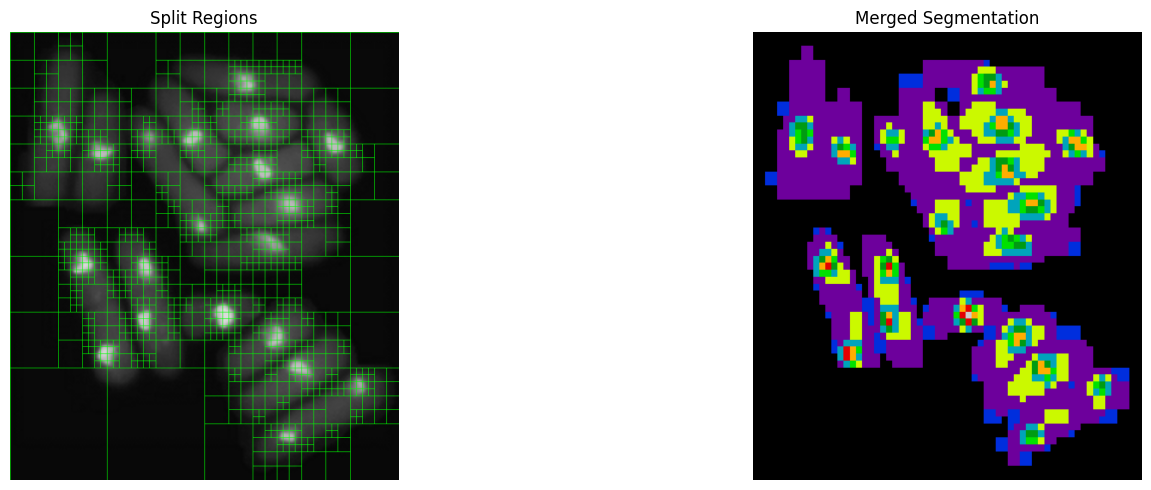

In [29]:
variance_threshold = 100      # Homogeneity criterion
merge_threshold = 15          # Mean difference for merging
min_size = 16                 # Minimum block size

rows, cols = img.shape
class Region:
    def __init__(self, x, y, w, h):
        self.x = x
        self.y = y
        self.w = w
        self.h = h

regions = []

def split(region): # Recursive Splitting

    block = img[region.y:region.y+region.h,
                region.x:region.x+region.w]

    variance = np.var(block)

    if (variance <= variance_threshold or
        region.w <= min_size or
        region.h <= min_size):

        regions.append(region)
        return

    w2 = region.w // 2
    h2 = region.h // 2

    split(Region(region.x, region.y, w2, h2))

    split(Region(region.x+w2, region.y,
                 region.w-w2, h2))

    split(Region(region.x, region.y+h2,
                 w2, region.h-h2))

    split(Region(region.x+w2, region.y+h2,
                 region.w-w2,
                 region.h-h2))

split(Region(0, 0, cols, rows))

print("Regions after splitting:", len(regions))

labels = np.zeros(img.shape, dtype=np.int32)
label = 1

for region in regions: # Region Merging

    block = img[region.y:region.y+region.h,
                region.x:region.x+region.w]

    mean = np.mean(block)

    merged = False

    for l in range(1, label):

        existing_pixels = img[labels == l]

        if len(existing_pixels) == 0:
            continue

        existing_mean = np.mean(existing_pixels)

        if abs(mean - existing_mean) < merge_threshold:

            labels[region.y:region.y+region.h,
                   region.x:region.x+region.w] = l

            merged = True
            break

    if not merged:

        labels[region.y:region.y+region.h,
               region.x:region.x+region.w] = label

        label += 1

display = np.zeros(img.shape, dtype=np.uint8) 
max_label = labels.max()
print("Final Regions:", max_label)
for l in range(1, max_label+1):
    display[labels == l] = int(255*l/max_label)

boundary = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

for region in regions:
    cv2.rectangle(boundary,(region.x, region.y), (region.x+region.w, region.y+region.h), (0,255,0), 1)
    
plt.figure(figsize=(18,5))

plt.subplot(1,2,1)
plt.imshow(boundary[:,:,::-1])
plt.title("Split Regions")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(display, cmap='nipy_spectral')
plt.title("Merged Segmentation")
plt.axis("off")

plt.tight_layout()
plt.show()